# Fastball Location Strategy by Count

`docs/purpose.md` frames workflow item 4 as: once a pitcher falls behind (or gets ahead),
does pitch *location* get more conservative, not just pitch selection? `count_state.ipynb`
already established that count has a large effect on resulting outcomes (resulting walk
rate ranges from 3.0% at 0-2 to 63.6% at 3-0). This notebook tests one concrete mechanism
for fastballs specifically: do pitchers locate fastballs more aggressively (corners/edges,
away from the heart of the plate) in counts that favor them, and more centrally ("just get
it over") in counts that favor the hitter?

This jumps ahead of purpose.md's item 3 (pitch-type-mix Plinko, not yet built). Answering
"does location shift with count" doesn't require the pitch-type-mix analysis to exist
first; only a later refinement of *how much* of any location effect is explained by
pitch-type mix changes would.

**Scope:** four-seam, sinker, and cutter (`FF`, `SI`, `FC`), the three types Baseball
Savant's public data groups under "Fastball". **Data:** `data/MLB_2021-2025.csv`,
2021-2025 Statcast, loaded with `usecols` matching `count_state.ipynb`'s convention.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

sys.path.insert(0, str(Path("..", "..", "pitching_plus", "scripts").resolve()))
import location as loc  # noqa: E402

DATA_PATH = Path("..", "..", "data", "MLB_2021-2025.csv")

FASTBALL_TYPES = {"FF", "SI", "FC"}
AB_KEY = ["game_pk", "at_bat_number"]

COUNT_ORDER = [
    (0, 0), (1, 0), (0, 1), (2, 0), (1, 1), (0, 2),
    (3, 0), (2, 1), (1, 2), (3, 1), (2, 2), (3, 2),
]

STRIKEOUT_EVENTS = {"strikeout", "strikeout_double_play"}
WALK_EVENTS = {"walk", "intent_walk"}
EXCLUDE_EVENTS = {"truncated_pa", "catcher_interf"}


def classify_result(ev):
    if ev in STRIKEOUT_EVENTS:
        return "strikeout"
    if ev in WALK_EVENTS:
        return "walk"
    if ev == "hit_by_pitch":
        return "hit_by_pitch"
    if ev in {"single", "double", "triple", "home_run"}:
        return "hit"
    return "out_or_other"


def count_label(balls, strikes):
    return f"{balls}-{strikes}"


In [2]:
usecols = [
    "game_pk", "at_bat_number", "pitch_number", "pitcher", "player_name",
    "pitch_type", "game_year", "balls", "strikes", "outs_when_up",
    "stand", "p_throws", "plate_x", "plate_z", "sz_top", "sz_bot", "zone",
    "on_1b", "on_2b", "on_3b", "delta_pitcher_run_exp", "events",
]

data = pd.read_csv(DATA_PATH, usecols=usecols)
data = data.sort_values(AB_KEY + ["pitch_number"]).reset_index(drop=True)
print(f"{len(data):,} pitches loaded")


3,565,743 pitches loaded


## Stage 0: How much is really riding on each count?

Before comparing locations across "favorable" and "unfavorable" counts, those buckets need
a definition grounded in data rather than a hand-picked ball/strike label. During planning,
a count like 2-1 turned out not to have an obvious label (it's a single pitch away from
both 3-1, a big hitter's count, and 2-2, where the strikeout rate jumps sharply).

Mirrors `count_state.ipynb`'s own resulting-outcome methodology directly: for every at-bat
that ever reaches a given count, what fraction eventually walks vs. strikes out? The
**resulting walk rate minus resulting strikeout rate** is a simple, transparent leverage
score: positive means the count tilts toward the hitter, negative toward the pitcher.

(A fuller run-value version of this, summing each pitch's actual `delta_pitcher_run_exp`
forward from the count's first pitch to the end of the at-bat, was tried first and
rejected: it ranks 3-0 as the *most* pitcher-favorable count of all 12, driven by a
right-skewed tail of high-value outs on balls put in play after reaching 3-0 outweighing
the much more common, but individually smaller-magnitude, walks. Mathematically sound, but
too counterintuitive to use as the basis for bucket boundaries here (see dev_log.md).)

In [3]:
ab_final = (
    data.dropna(subset=["events"])
    .drop_duplicates(subset=AB_KEY, keep="last")
)
ab_final = ab_final[~ab_final["events"].isin(EXCLUDE_EVENTS)].copy()
ab_final["result"] = ab_final["events"].apply(classify_result)
ab_outcomes = ab_final.set_index(AB_KEY)["result"]

visits = (
    data.drop_duplicates(subset=AB_KEY + ["balls", "strikes"])[AB_KEY + ["balls", "strikes"]]
    .set_index(AB_KEY)
    .join(ab_outcomes, how="inner")
    .reset_index()
)

resulting = visits.groupby(["balls", "strikes"])["result"].value_counts(normalize=True).unstack(fill_value=0)
resulting["n_abs_through"] = visits.groupby(["balls", "strikes"]).size()
resulting = resulting.reset_index()
resulting["count_label"] = [count_label(b, s) for b, s in zip(resulting["balls"], resulting["strikes"])]
resulting["bb_minus_k"] = resulting.get("walk", 0) - resulting.get("strikeout", 0)
resulting = resulting.sort_values("bb_minus_k").reset_index(drop=True)
resulting["leverage_rank"] = resulting.index + 1  # 1 = most pitcher-favorable

# cross-check against count_state.ipynb's already-established numbers
assert resulting.loc[resulting.count_label == "0-0", "n_abs_through"].iloc[0] == 912_449
assert resulting.loc[resulting.count_label == "0-1", "n_abs_through"].iloc[0] == 459_559
print("Cross-check against count_state.ipynb passed: n_abs_through matches at 0-0 and 0-1.")

resulting[["leverage_rank", "count_label", "strikeout", "walk", "bb_minus_k", "n_abs_through"]].round(4)


Cross-check against count_state.ipynb passed: n_abs_through matches at 0-0 and 0-1.


result,leverage_rank,count_label,strikeout,walk,bb_minus_k,n_abs_through
0,1,0-2,0.4630,0.0304,-0.4326,195796
1,2,1-2,0.4336,0.0592,-0.3745,271658
2,3,0-1,0.3073,0.0503,-0.2570,459559
3,4,2-2,0.3828,0.1263,-0.2564,221304
4,5,1-1,0.2766,0.0947,-0.1819,357701
5,6,0-0,0.2264,0.0841,-0.1423,912449
6,7,1-0,0.1870,0.1535,-0.0336,349302
7,8,2-1,0.2270,0.1953,-0.0316,184290
8,9,3-2,0.2813,0.3190,0.0377,127614
9,10,2-0,0.1416,0.3084,0.1668,119666


In [4]:
order = resulting.sort_values("leverage_rank")["count_label"].tolist()
colors = ["#c0392b" if v > 0 else "#2a78d6" for v in resulting.sort_values("leverage_rank")["bb_minus_k"]]

fig = go.Figure(go.Bar(
    x=order,
    y=resulting.sort_values("leverage_rank")["bb_minus_k"],
    marker_color=colors,
))
fig.update_layout(
    title="Count leverage: resulting BB% minus resulting K%, pitcher-favorable to hitter-favorable",
    xaxis_title="Count (ordered by leverage)",
    yaxis_title="Resulting BB% - Resulting K%",
    yaxis_tickformat=".0%",
    template="plotly_white",
)
fig.show()


**Where 2-1 lands:** rank 8 of 12 (higher rank = more hitter-favorable). Its
BB%-K% differential is essentially tied with 1-0 (about -3% each), sitting right at the
boundary between "even" and "hitter-ahead," and much closer to 3-2 (the next most
pitcher-favorable neighbor) than to 0-0. That confirms the intuition from `count_state.ipynb`'s
K-rate chart: 2-1 isn't cleanly "even" the way its 0-1 ball/strike differential might
suggest; it's a pivot point.

In [5]:
BUCKET_BOUNDS = [0, 4, 8, 12]
BUCKET_LABELS = ["Pitcher-ahead", "Even", "Hitter-ahead"]
resulting["bucket"] = pd.cut(resulting["leverage_rank"], bins=BUCKET_BOUNDS, labels=BUCKET_LABELS)
count_to_bucket = dict(zip(zip(resulting["balls"], resulting["strikes"]), resulting["bucket"]))
count_to_rank = dict(zip(zip(resulting["balls"], resulting["strikes"]), resulting["leverage_rank"]))

resulting.sort_values("leverage_rank")[["leverage_rank", "count_label", "bucket"]]


result,leverage_rank,count_label,bucket
0,1,0-2,Pitcher-ahead
1,2,1-2,Pitcher-ahead
2,3,0-1,Pitcher-ahead
3,4,2-2,Pitcher-ahead
4,5,1-1,Even
5,6,0-0,Even
6,7,1-0,Even
7,8,2-1,Even
8,9,3-2,Hitter-ahead
9,10,2-0,Hitter-ahead


## Stage A: Where do fastballs actually go, by count bucket?

Zone-relative, handedness-normalized coordinates (`pitching_plus/scripts/location.py`'s own
`_build_features`, reused directly rather than reimplemented): `plate_x_armside` (positive =
arm-side of the pitcher's own throwing hand) and `plate_z_rel` (0 = bottom of this batter's
zone, 1 = top). True hexagonal binning is a matplotlib feature Plotly doesn't have a native
equivalent for, so this one chart uses matplotlib (as `count_state.ipynb`'s own first chart
does) rather than the Plotly convention used everywhere else in this notebook.

In [6]:
fb = data[data["pitch_type"].isin(FASTBALL_TYPES)].copy()
in_scope = fb.dropna(subset=loc.REQUIRED_COLS).copy()
engineered = loc._build_features(in_scope)
engineered["bucket"] = [count_to_bucket.get((b, s)) for b, s in zip(engineered["balls"], engineered["strikes"])]
print(f"{len(engineered):,} / {len(fb):,} fastballs in scope for location analysis")

# a numeric companion to the hexbins, since a chart's shape isn't something to assert on
# without seeing it rendered: how far from the center of the zone are fastballs, on average,
# per bucket.
dispersion = engineered.groupby("bucket", observed=True).agg(
    mean_abs_x=("plate_x_armside", lambda s: s.abs().mean()),
    mean_z_dist_from_mid=("plate_z_rel", lambda s: (s - 0.5).abs().mean()),
    pct_in_heart_x_band=("plate_x_armside", lambda s: (s.abs() <= 0.83).mean()),
    n=("plate_x_armside", "size"),
)
dispersion


1,992,437 / 1,992,591 fastballs in scope for location analysis


,mean_abs_x,mean_z_dist_from_mid,pct_in_heart_x_band,n
bucket,,,,
Even,0.623057,0.363665,0.711613,1055942
Hitter-ahead,0.573923,0.346589,0.752122,288686
Pitcher-ahead,0.659559,0.436588,0.682775,647809


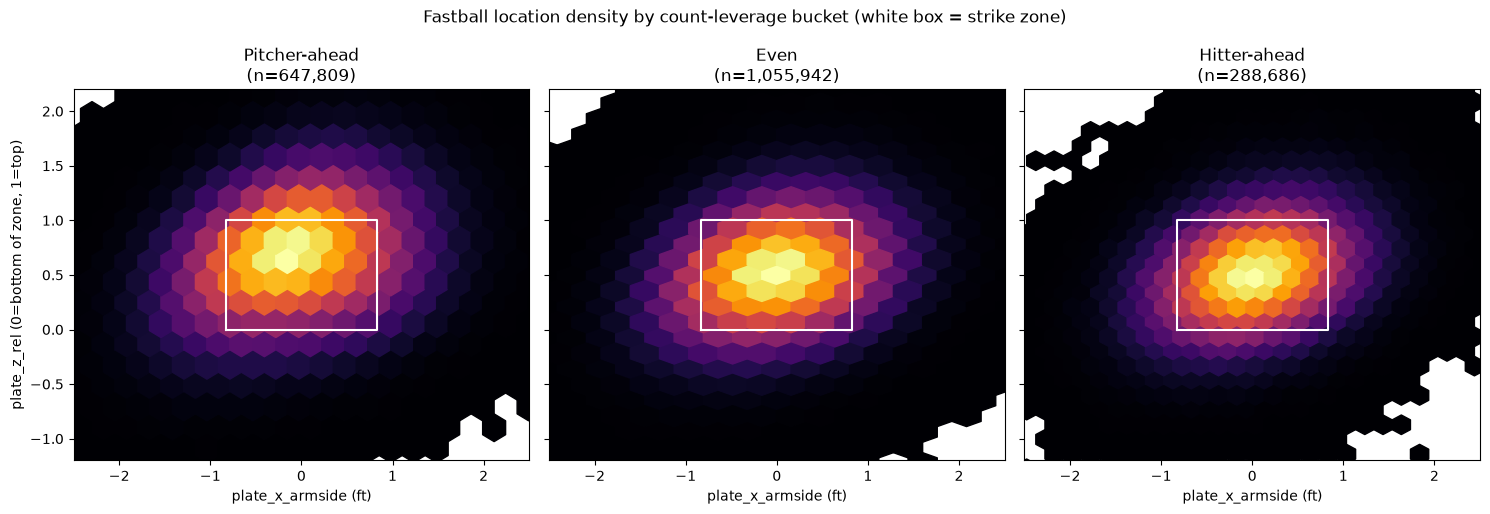

In [7]:
ZONE_HALF_WIDTH_FT = 0.83  # standard plate-width-plus-ball-radius approximation

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharex=True, sharey=True)
for ax, bucket in zip(axes, BUCKET_LABELS):
    sub = engineered[engineered["bucket"] == bucket]
    ax.hexbin(sub["plate_x_armside"], sub["plate_z_rel"], gridsize=40, cmap="inferno", mincnt=1)
    ax.plot(
        [-ZONE_HALF_WIDTH_FT, ZONE_HALF_WIDTH_FT, ZONE_HALF_WIDTH_FT, -ZONE_HALF_WIDTH_FT, -ZONE_HALF_WIDTH_FT],
        [0, 0, 1, 1, 0],
        color="white", linewidth=1.5,
    )
    ax.set_title(f"{bucket}\n(n={len(sub):,})")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-1.2, 2.2)
    ax.set_xlabel("plate_x_armside (ft)")
axes[0].set_ylabel("plate_z_rel (0=bottom of zone, 1=top)")
fig.suptitle("Fastball location density by count-leverage bucket (white box = strike zone)")
fig.tight_layout()
plt.show()


The same pattern shows up in raw distance terms. Pitcher-ahead fastballs sit furthest
from the center of the zone on both axes (mean |plate_x_armside| 0.66 ft, mean distance
from mid-height 0.44) and are least concentrated near the heart-width band (68.3% within
+/-0.83 ft). Hitter-ahead fastballs are the tightest cluster on both axes (0.57 ft / 0.35,
75.2% within the heart-width band), the smallest spread of any bucket on either axis.
"Even" sits in between on every metric. The hexbins above should show that directly: a
wider, more corner/chase-seeking spray in the left panel, and a visibly tighter cluster
hugging the zone in the right one.

## Stage B: Zone-code distribution by count

A cheaper, model-free confirmation of whatever Stage A's hexbins suggest visually: group
Statcast's own `zone` column the same way `pitching_plus/scripts/bestpitch.py`'s
`CANDIDATE_ZONE_CODES` already does: Heart (5), Edge (2,4,6,8), Corner (1,3,7,9), Chase/Ball
(11-14 and everything else), then compute each bucket's share of fastballs by count.

In [8]:
HEART = {5}
EDGE = {2, 4, 6, 8}
CORNER = {1, 3, 7, 9}


def zone_bucket(z):
    if z in HEART:
        return "Heart"
    if z in EDGE:
        return "Edge"
    if z in CORNER:
        return "Corner"
    return "Chase/Ball"


fb["zone_bucket"] = fb["zone"].apply(zone_bucket)
fb["count_label"] = [count_label(b, s) for b, s in zip(fb["balls"], fb["strikes"])]

zone_dist = fb.groupby(["count_label", "zone_bucket"]).size().unstack(fill_value=0)
zone_dist_pct = zone_dist.div(zone_dist.sum(axis=1), axis=0).reindex(order)
(zone_dist_pct * 100).round(1)


zone_bucket,Chase/Ball,Corner,Edge,Heart
count_label,,,,
0-2,60.5,15.8,18.6,5.2
1-2,54.9,17.4,21.4,6.2
0-1,49.6,19.0,24.0,7.4
2-2,46.7,19.5,25.6,8.3
1-1,45.5,19.8,26.3,8.5
0-0,43.9,20.0,27.1,9.0
1-0,41.8,20.7,28.1,9.4
2-1,40.5,20.8,28.9,9.9
3-2,37.9,21.1,30.2,10.8


In [9]:
zone_colors = {"Heart": "#c0392b", "Corner": "#eda100", "Edge": "#2a78d6", "Chase/Ball": "#c3c2b7"}
fig = go.Figure()
for cat in ["Heart", "Corner", "Edge", "Chase/Ball"]:
    fig.add_trace(go.Scatter(
        x=order, y=zone_dist_pct[cat], mode="lines+markers", name=cat,
        line=dict(color=zone_colors[cat], width=2.5), stackgroup=None,
    ))
fig.update_layout(
    title="Fastball zone-code share by count (ordered pitcher-ahead -> hitter-ahead)",
    xaxis_title="Count (ordered by leverage)",
    yaxis_title="Share of fastballs",
    yaxis_tickformat=".0%",
    template="plotly_white",
)
fig.show()


Heart% and Corner% both roughly *double* from the most pitcher-favorable counts to the most
hitter-favorable ones (Heart% ~5-7% at 0-2/1-2/0-1 vs. ~10-11% at 3-0/3-1/2-0; Corner%
~16-19% vs. ~21%), while Chase/Ball% falls sharply in the other direction (~55-60% at
0-2/1-2 vs. ~37-40% at 3-0/3-1/2-0). That's a nuance on the "getting cute vs. just get it
over" framing: pitchers in must-throw-a-strike counts aren't specifically aiming for dead
center over corners (Corner% actually *rises* right alongside Heart%); they're compressing
their target away from clearly-out-of-zone chase pitches toward *anywhere* in or near the
zone, heart or corner alike. The two-strike, pitcher-ahead counts are where the *chase*
pitch becomes the dominant strategy, not where corner-hunting disappears.

## Stage C: Location+ "meatball gap" by count

Stage B measures *where* fastballs go; this measures whether that choice pays off, in the
same run-value currency `pitching_plus/scripts/location.py`'s Location+ model is trained on.

Caveat: a raw average of `pitch_location_plus` (or `location_run_value`) by count would
conflate two different things: the count's own baked-in stakes (`balls`/`strikes`/
`re288_state` are Location+ model features) and the actual quality of the location chosen.
That's not a fair "did pitchers locate well here" comparison. Instead, for every real
fastball, score a counterfactual "meatball" through the identical trained model for that
pitch type (same count, same situation, but `plate_x_armside=0, plate_z_rel=0.5`, dead
center), the same held-situation-fixed pattern `bestpitch.py`'s `_predict_at_point` already
uses for its own counterfactual search, just with one fixed reference point instead of a
full candidate search. **Gap = actual - meatball**: positive means the real, chosen location
beat a hypothetical grooved pitch in that exact situation; negative means it didn't.

In [10]:
scored = loc.add_location_plus(fb, retrain=False)

meatball_pred = pd.Series(np.nan, index=engineered.index, dtype=float)
models = loc.load_cached_models()
for ptype in FASTBALL_TYPES:
    if ptype not in models:
        continue
    rows = engineered["pitch_type"] == ptype
    if not rows.any():
        continue
    X = engineered.loc[rows, loc.LOCATION_FEATURES].copy()
    X["plate_x"] = 0.0
    X["plate_z_rel"] = 0.5
    X["plate_x_armside"] = 0.0
    meatball_pred.loc[rows] = models[ptype].predict(X[loc.LOCATION_FEATURES].to_numpy())

engineered["meatball_run_value"] = meatball_pred
engineered = engineered.merge(
    scored[loc.KEY_COLS + ["location_run_value"]], on=loc.KEY_COLS, how="left",
)
engineered["meatball_gap"] = engineered["location_run_value"] - engineered["meatball_run_value"]
print(f"{engineered['meatball_gap'].notna().sum():,} fastballs with a meatball_gap value")

gap_by_count = (
    engineered.dropna(subset=["meatball_gap"])
    .assign(count_label=lambda d: [count_label(b, s) for b, s in zip(d["balls"], d["strikes"])])
    .groupby("count_label")["meatball_gap"]
    .agg(["mean", "count"])
    .reindex(order)
)
gap_by_count

1,992,437 fastballs with a meatball_gap value


,mean,count
count_label,,
0-2,0.029037,108649
1-2,0.024068,157562
0-1,0.002991,235346
2-2,0.004925,146252
1-1,0.000191,183927
0-0,-0.002637,552999
1-0,-0.005324,208975
2-1,-0.017662,110041
3-2,-0.040475,111010


In [11]:
fig = go.Figure(go.Bar(
    x=gap_by_count.index,
    y=gap_by_count["mean"],
    marker_color=["#c0392b" if v < 0 else "#2a78d6" for v in gap_by_count["mean"]],
))
fig.update_layout(
    title="Location+ 'meatball gap' by count: actual fastball location value vs. a dead-center pitch, same situation",
    xaxis_title="Count (ordered pitcher-ahead -> hitter-ahead)",
    yaxis_title="Mean run-value gap (actual - meatball)",
    template="plotly_white",
)
fig.show()


The gap is positive in the two-strike, pitcher-ahead counts (0-2, 1-2: real locations
meaningfully beat a hypothetical grooved pitch there) and increasingly negative moving
toward 3-0/3-1/2-0 (real locations underperform the dead-center counterfactual). Read
together with Stage B, this doesn't mean dead-center is a *bad* target in hitter's counts:
the model scores the meatball point itself highly in those counts, since a called strike is
valuable enough there that center-cut is a strong target on paper. Real pitchers' actual
execution in must-strike counts falls short of that idealized center point on average
(normal command variance under pressure), while in two-strike counts, real
(edge/chase-seeking) locations have room to beat a center-cut pitch, because a hittable
meatball costs the pitcher once the batter no longer has to protect the plate as much.

## The 2-1 fork

Stage 0 flagged 2-1 as a pivot rather than a clean "even" count. Every at-bat at 2-1
is one pitch from either 3-1 (a hitter's count, leverage rank near the top) or 2-2 (a
pitcher's count, leverage rank near the bottom), a much bigger fork than a single ball
or strike would suggest from the count alone.

In [12]:
# the single pitch thrown at 2-1 (balls/strikes can't repeat at 2-1 within an AB, since
# any outcome there either ends the AB or advances the count, so there's one row per at-bat).
pitch21 = data[(data["balls"] == 2) & (data["strikes"] == 1)][AB_KEY + ["pitch_number"]]
pitch21 = pitch21.rename(columns={"pitch_number": "p21"})

next_pitch = data.merge(pitch21, on=AB_KEY).query("pitch_number == p21 + 1")
branch = np.where(
    (next_pitch["balls"] == 3) & (next_pitch["strikes"] == 1), "-> 3-1",
    np.where((next_pitch["balls"] == 2) & (next_pitch["strikes"] == 2), "-> 2-2", "other"),
)
next_pitch = next_pitch[AB_KEY].assign(branch=branch)
next_pitch = next_pitch[next_pitch["branch"] != "other"].set_index(AB_KEY)

branch_outcomes = ab_outcomes.reindex(next_pitch.index).to_frame("result")
branch_outcomes["branch"] = next_pitch["branch"]
branch_outcomes = branch_outcomes.dropna(subset=["result"])

branch_summary = branch_outcomes.groupby("branch")["result"].value_counts(normalize=True).unstack(fill_value=0)
branch_summary["n"] = branch_outcomes.groupby("branch").size()
branch_summary[["strikeout", "walk", "hit", "n"]].round(4)

result,strikeout,walk,hit,n
branch,,,,
-> 2-2,0.3832,0.1328,0.1512,89468
-> 3-1,0.1399,0.4471,0.1364,53929


The two branches out of 2-1 land in almost opposite places. At-bats that go to 3-1 next:
44.7% eventually walk, only 14.0% strike out. At-bats that go to 2-2 next: 38.3% eventually
strike out, only 13.3% walk, a near-total reversal of the K%/BB% split on a single pitch's
difference. That's the concrete version of the divergence `count_state.ipynb`'s K-rate chart
hinted at: 2-1 isn't a stable "even" count so much as a coin flip between two counts that
pull in opposite directions, which is exactly why Stage 0 placed it right on the
Even/Hitter-ahead boundary rather than cleanly in the middle.

## Synopsis

- **Stage 0**: a transparent resulting BB%-K% differential (not a raw per-pitch or
  cumulative run-value sum; see the note above on why that alternative was rejected) ranks
  the 12 counts pitcher-favorable to hitter-favorable. 2-1 lands right at the boundary
  between "even" and "hitter-ahead," essentially tied with 1-0 and much closer to the
  hitter-favorable cluster than a naive 1-ball-1-strike reading would suggest.
- **Stage A/B**: fastball location shifts materially with count leverage, but not simply
  "center vs. corner": Heart% and Corner% move together (both roughly double from
  pitcher-ahead to hitter-ahead counts), while the real swing is Chase/Ball% falling as
  leverage moves toward the hitter. The two-strike counts are where pitchers can afford to
  leave the zone; the deep-ball counts are where they compress toward anywhere hittable.
- **Stage C**: Location+'s "meatball gap" (actual vs. a dead-center counterfactual, same
  situation) is positive in two-strike counts and negative in hitter-favorable counts:
  real fastball locations add value over a grooved pitch when the pitcher can afford to
  miss the zone, and fall short of even a hypothetical center-cut pitch's expected value
  when they can't.
- **2-1 fork**: the branch split's outcome rates are the direct, data-driven answer to
  whether 2-1's two possible next stops (3-1 vs. 2-2) diverge as sharply as the K-rate
  chart suggested.

**Deferred**: per-pitcher case studies (Graham Ashcraft, Dustin May, purpose.md's own
named inspirations), a full `bestpitch.py`-style multi-candidate counterfactual search
restricted to fastballs (documented multi-hour cost at full scale), and extending this same
pipeline to breaking/offspeed pitch types for contrast.